# Building materials workflows without writing code

### A hands-on introduction to **pyiron aiflow**

Presenters: Dr. Jan Janssen, Prof. Dr. Jörg Neugebauer, Max Planck Institute for Sustainable Materials


The objective of this session is that at the end you will have:

1. built a complete process–property model yourself, in a visual editor;
2. run a real simulation related to materials design and changed key process parameters to understand their impact on materials properties;
3. seen a workflow that an AI assistant wrote from a single sentence — and, more
   importantly, seen how to *check* it.

| Part | Task | 
|---|---|
| **0** | Why an explicit workflow layer |
| **1** | Open the editor | 
| **2** | Build a workflow by hand | 
| **3** | Group it, sweep it, and see the code it wrote | 
| **4** | An AI-generated workflow, and what that means for research | 
| **5** | Where to go next | 

---

## Part 0 — Why an explicit workflow layer

A materials property is almost never one calculation. It is a **chain**:

```
 composition / process data  →  model  →  property  →  decision
```

In day-to-day practice that chain lives in three scripts, a spreadsheet, and one person's
head. That works, right up until it doesn't. Five things break, and they will all be
familiar:

| What breaks | How it shows up |
|---|---|
| **Provenance** | A number is in a report. Which potential, which mesh, which temperature produced it? Nobody can say. |
| **Reuse** | The same Hall–Petch fit gets retyped for every project, slightly differently each time. |
| **Parameter studies** | A `for` loop over 5 temperatures is easy. The same study over 500, on a cluster, is a rewrite. |
| **Handover** | The chain leaves the company when the person does. |
| **Scale-out** | Moving from a laptop to a compute cluster means touching the science code. |

A workflow framework fixes these by making the chain itself an **object** — something
that exists, can be looked at, and can be handed to someone else. Once the chain is an
object rather than a habit, it is inspectable, re-runnable, cacheable, transferable,
parallelisable, and comparable between two versions.

**And you do not have to write code to build one.** In aiflow, the chain is a *graph*,
and that one graph has three interfaces:

![One typed workflow graph - Linspace, GrainGrowth, HallPetch, PlotYieldStrength - exposed through three interfaces: visual editor, Python, and AI assistant.](figures/intro_three_interfaces.svg)

Today is mostly the visual editor. The Python and the AI assistant will show up at the
end — and you will see that they are producing exactly the same thing you built by hand.

---

## Part 1 — Open the editor

Run the cell below. (Click it and press **Shift + Enter**. That is the only
keyboard skill this session requires.)

In [1]:
from pyironflow import PyironFlow

In [2]:
PyironFlow()

![basic](figures/basic.png)

### What you are looking at

**Left — the node browser.** A searchable library of ready-made building blocks, in two
sections:
- **Nodes** — individual operations (build a crystal, fit a curve, apply a potential).
- **Workflows** — complete, saved chains that other people have built.

**Middle — the canvas.** Where your workflow lives.

**Right — the inspector**, with tabs: **output** (results), **log** (what happened),
**description** (what this workflow is for), **source**, **settings**.

**Top-right of the canvas** — buttons to re-tidy the layout, **Clear** the canvas,
**Group selected nodes**, and **Convert to Python code**.

**Top bar** — the workflow's name, **Save**, **Restore**, and `+` to open another
workflow in a new tab.

### The only three concepts you need

| Term | What it means |
|---|---|
| **Node** | One step. It takes some inputs and produces some outputs. |
| **Port** | One input or one output of a node — the little dots on its edge. |
| **Edge** | A line saying *"this result becomes that input."* |

And one rule that explains the rest:

> **Pressing ▶ Run on a node runs everything that node depends on, first.**

There is no separate "run the whole workflow" button, because there does not need to be.
Run the last node and the whole chain executes in the right order. Run it again after
changing one number and only the affected part is recomputed.

---

## Part 2 — Build a workflow by hand  

**This is the main exercise.** Use the empty canvas above.

The model: *a steel is annealed; its grains coarsen; coarser grains mean lower yield
strength.* We want the strength as a function of the annealing schedule.

Here is the target — what your canvas should look like once the seven steps below are done:

<img src="figures/intro_workflow_chain.svg" width="900"
     alt="Four connected nodes: Linspace feeds GrainGrowth, whose grain size output feeds both HallPetch and PlotYieldStrength.">

### Step by step

**1. The annealing times.**
In the search box on the left, type `Linspace`. Drag it onto the canvas.
Set `x_min = 10`, `x_max = 240`, `num_points = 40` — annealing times from 10 minutes
to 4 hours.

> *Why a node and not just a list of numbers?* Because now the range is part of the
> workflow. Anyone who opens it can see it and change it — it isn't buried inside a
> script.

**2. The grain-growth model.**
Search for `GrainGrowth` and drag it on. Now connect them: **click and drag from the
`linspace` output dot on the right of the Linspace node, to the `time` input dot on
the GrainGrowth node.** A line appears — that is your first edge.

Set `temperature_K = 1123` (850 °C).

**3. Run it early.**
Press **▶ Run** on the GrainGrowth node and look at the **output** tab. You should see
an array of grain sizes, rising from about **12.9 µm** to about **58.4 µm**.

Notice that **you never ran the Linspace node.** aiflow worked out that it was needed
and ran it for you. That is the dependency rule doing its job.

**4. The strength model.**
Drag on `HallPetch`. Connect `GrainGrowth.grain_size_um` → `HallPetch.grain_size_um`.

**5. The plot.**
Drag on `PlotYieldStrength`. This one needs **two** connections:
- `GrainGrowth.grain_size_um` → `grain_size_um`
- `HallPetch.sigma_y_MPa` → `sigma_y_MPa`

Press **▶ Run** on the plot node. The figure appears in the **output** tab: yield
strength falling from roughly **276 MPa** to **167 MPa** as the grains coarsen.

**6. Now change something.**
Set `temperature_K = 1223` and press **▶ Run** again. Watch the downstream nodes mark
themselves as out of date, then recompute. The strength drops further — the hotter
anneal coarsens the microstructure more.

**7. Save it.**
Type a name — `anneal_and_strength` — in the top bar and press **Save**. It now appears
under **Workflows** in the left-hand browser, and your colleague can open it by name.

### Stop and notice what just happened

You built a complete, documented, re-runnable process–property model. It is saved, it is
shareable, and every assumption in it — the temperature, the time range, the Hall–Petch
constants — is visible on screen rather than buried in someone's script.

**The only thing you typed was numbers.**

---

## Part 3 — Group it, sweep it, and see the code it wrote 

### Grouping: making a reusable process step

Click the `GrainGrowth` node, then shift-click `HallPetch` so both are selected. Press
**Group selected nodes**.

The two nodes collapse into one. You now have a single *"anneal and strengthen"* step
with a temperature and a time going in and a strength coming out. Use **Expand** to look
inside it, **Collapse** to close it again, **Ungroup** to undo.

This is how a piece of your group's know-how becomes a reusable component. The internals
are still there and still auditable — they are just not in the way any more.

### Sweeping: the parameter study you didn't have to write

*(Watch this one — your presenter will demonstrate it.)*

Drag on an `IterToDataFrame` node. Connect your new group node into its `node` port (it
draws as a dashed line — it means "this is the thing to repeat"), set
`input_label = "temperature_K"`, and feed its `values` from a second `Linspace`.

Run it. You get a table of yield strength against annealing temperature.

Two things worth pointing out:

- The swept values come from a **node**, not a typed-in list, so the range stays a
  visible, editable part of the workflow.
- Every node has an **executor** port (under the **Ports ▾** menu). Wire a cluster
  executor into it and this same graph runs its 40 cases in parallel on a compute
  cluster. *The science part does not change at all.* This is the step that is normally
  a rewrite.

### The reveal
(Not part of our hands-on session but you may later run it.)

Press **Convert to Python code**.

The workflow you just built by dragging appears as clean, readable Python. **You have
been writing code all along** — you just did it with a mouse. If you ever want to read
it, edit it, put it under version control, or send it to a colleague who prefers text,
it is right there.

It works in the other direction too. Here is that same workflow written directly in
Python:

In [3]:
from core import Workflow
from pyiron_nodes.math_utils import Linspace
from pyiron_nodes.tutorial.heat_treatment import GrainGrowth, HallPetch, PlotYieldStrength

wf = Workflow("anneal_and_strength")
wf.anneal_times = Linspace(x_min=10, x_max=240, num_points=40)
wf.grain = GrainGrowth(temperature_K=1123.0, time=wf.anneal_times)
wf.strength = HallPetch(grain_size_um=wf.grain)
wf.plot = PlotYieldStrength(grain_size_um=wf.grain, sigma_y_MPa=wf.strength)

wf.run()

d = wf.grain.outputs.grain_size_um.value
s = wf.strength.outputs.sigma_y_MPa.value
print(f"grain size     {d[0]:.1f} um  ->  {d[-1]:.1f} um")
print(f"yield strength {s[0]:.0f} MPa  ->  {s[-1]:.0f} MPa")

grain size     12.9 um  ->  58.4 um
yield strength 276 MPa  ->  167 MPa


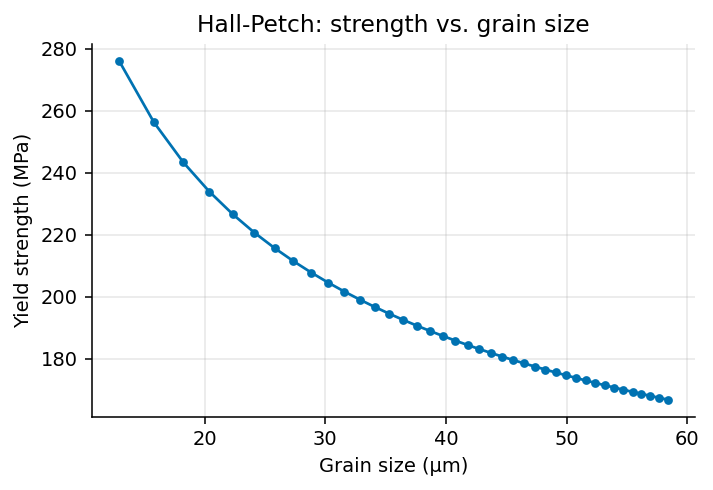

In [4]:
wf.plot.outputs.fig.value

Five lines of Python and seven drag-and-drop steps produce **the same object**. Send this
workflow to the editor and it appears on the canvas, laid out and ready to run.

The editor opens with two tabs: your `anneal_and_strength` workflow on the left, and `anneal_and_strength_loop` — the swept version from Part 3 — on the right.

In [5]:
PyironFlow([wf, "anneal_and_strength_loop"])

![loop](figures/loop.png)

### One more thing the graph buys you: caching

Every node has a **store** switch in its **Ports ▾** menu. Turn it on and the node's
result is filed away under a fingerprint of its inputs. Next time anything asks for the
same computation with the same inputs, it is loaded instead of recomputed — and the node
lights up to tell you it came from cache.

For a 30-millisecond Hall–Petch fit this is irrelevant. For a three-hour DFT calculation that
sits upstream of a plot you keep re-tweaking, it is the difference between a workflow you
use and one you avoid. *(It needs a database server, so we are describing it rather than
running it today.)*

---

## Part 4 — An AI-generated workflow 

### The question

High-manganese austenitic steels get their remarkable combination of strength and
ductility from *how* they deform. Two mechanisms compete, and which one wins is set by a
single quantity — the **stacking fault energy** (SFE):

| SFE | Dominant mechanism | |
|---|---|---|
| **< 20 mJ/m²** | **TRIP** | strain-induced γ → ε martensite |
| **20 – 45 mJ/m²** | **TWIP** | mechanical twinning |
| **> 45 mJ/m²** | ordinary slip | |

and the SFE follows from composition through the Olson–Cohen/Allain model:

$$\mathrm{SFE} = 2\rho\,\Delta G^{\gamma\rightarrow\varepsilon} + 2\sigma$$

Getting from *"here is my composition"* to *"here is the deformation mechanism"* means
chaining half a dozen models together. That is precisely a workflow.

### The prompt

The workflow you are about to open was not written by a person. It was generated from
**one sentence**:

> *"Make a workflow that tells for a given `Fe_(1-x)X_x` high-strength steel whether its
> deformation process is dominated by the TRIP or the TWIP process."*

That sentence went into the **AI Assistant** panel in this same editor. The assistant
searched the node library, drafted a graph, **ran it**, read the errors, repaired them,
re-ran, and finally tidied the layout. Its controls are the ones you would expect:
which model, *create* a new workflow or *edit* the open one, just check that it builds or
insist that it actually executes, and how many repair attempts to allow.

*(We generated it ahead of time so we are not waiting on an API during the session.)*

In [6]:
PyironFlow(["Steel_TWIP_TRIP"])

![steel](figures/steel.png)

### Try it

1. Read the **description** tab. The assistant documented its own workflow.
2. Press **▶ Run** on `alloy_verdict` and read the verdict in the **output** tab.
3. Open `mode_map_plot` and `mode_map_table` — the SFE across the whole composition range,
   with the TRIP / TWIP / slip regions marked.
4. Press **Expand** on the `compute` node. Those eight inner nodes are the physics:
   lattice parameter → planar packing density → driving force ΔG → SFE → martensite
   accessibility → classification. **Every intermediate is a port you can click on.**
5. **Change the answer**: in `alloy_definition`, set `x_solute` from `0.22` to `0.32` and
   re-run. The verdict flips from **TRIP-dominated** to **TWIP-dominated**.
6. Set `solute_element` to `Al` and re-run. Notice that the verdict now prints a
   calibration warning about itself.

In [7]:
# The same thing headless, so the numbers are on the page for anyone reading later.
from core import Workflow
from pathlib import Path
from core.config import paths

# The shared workflow library - exactly what the browser's "Workflows" section shows.
WORKFLOWS = Path(paths.WORKFLOW_STORAGE)
from IPython.display import Markdown, display

steel = Workflow.load(WORKFLOWS / "Steel_TWIP_TRIP.py")
steel.alloy_definition.inputs.x_solute.value = 0.22
steel.run()
display(Markdown(steel.alloy_verdict.outputs.verdict.value))

# Fe(1-x)Mn(x), x = 0.220 (22.0 at.% Mn) at 300 K

**Verdict: TRIP-dominated (strain-induced gamma -> epsilon martensite)**

- Stacking fault energy: **15.6 mJ/m^2**
- Driving force dG(gamma->epsilon): -421 J/mol (epsilon stable)
- Md(epsilon): 445 K -- deformation temperature is below it, so the transformation can be triggered mechanically
- TRIP/TWIP boundary of this system: x = 0.268 (26.8 at.% Mn); the alloy sits -4.8 at.% from it

In [8]:
steel.alloy_definition.inputs.x_solute.value = 0.32
steel.run()
display(Markdown(steel.alloy_verdict.outputs.verdict.value))

# Fe(1-x)Mn(x), x = 0.320 (32.0 at.% Mn) at 300 K

**Verdict: TWIP-dominated (mechanical twinning)**

- Stacking fault energy: **23.8 mJ/m^2**
- Driving force dG(gamma->epsilon): -283 J/mol (epsilon stable)
- Md(epsilon): 417 K -- deformation temperature is below it, so the transformation can be triggered mechanically
- TRIP/TWIP boundary of this system: x = 0.268 (26.8 at.% Mn); the alloy sits +5.2 at.% from it

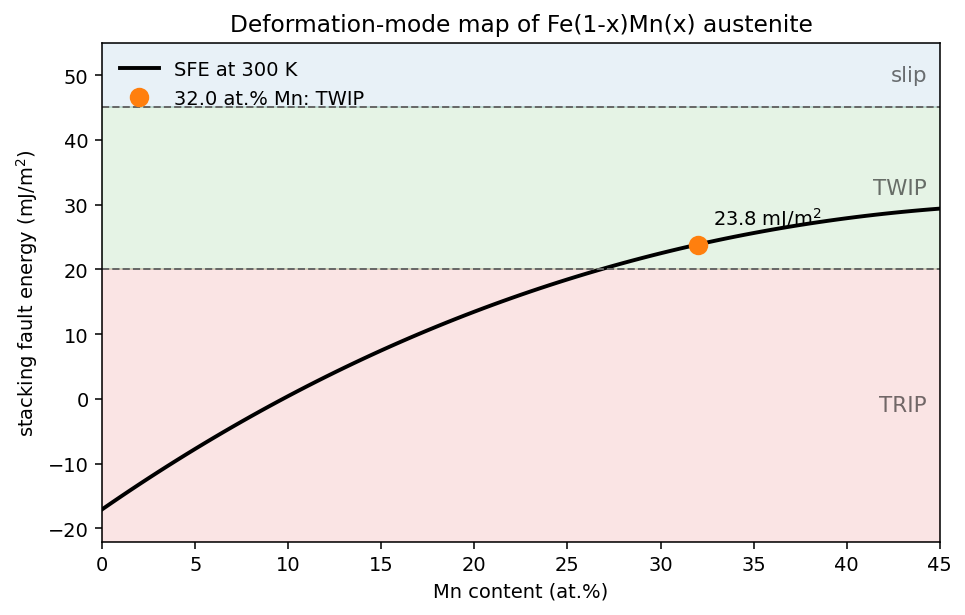

In [9]:
steel.mode_map_plot.outputs.fig.value

---

## Why this matters for AI-guided research

This is the part worth taking back to the office.

**1. An LLM can already write you a script. That is not the problem.**
The problem is what you get: a few hundred lines you have to read carefully before you
can trust the number at the bottom, that don't compose with the next script it writes,
and that keep no record of what was actually run. You have traded "I did the work" for
"I have to review the work," and reviewing is often the slower half.

**2. A node library is a constrained vocabulary.**
When the assistant builds a graph, it selects from named, typed, documented operations
instead of inventing API calls from memory. Connecting an energy where a structure is
expected is rejected when the graph is *built* — not silently coerced into a wrong number
two hours later.

**3. The graph is something a machine can check.**
Because the workflow is a data structure, an automated harness can ask: does it parse?
does it construct? does it execute? are the values physically plausible? does it survive
being saved and reloaded? Each failure goes back to the model as a specific, actionable
error. **Verification is inside the loop, not something you do afterwards.**

**4. Auditability is the point, not a bonus.**
A number from an agent is worth nothing if you cannot interrogate how it was produced. In
that steel workflow, ΔG, the packing density, the SFE, and `M_d` are each a port you can
click. **You audit the model, not just the answer.** This is the thing that makes
human-in-the-loop actually possible rather than merely aspirational — and you saw a
concrete case of it in Part 4, where an unsupported fit was hiding behind a plausible
number until you looked at the curve.

**5. One representation, three consumers.**
You on the canvas, your colleague in Python, the agent through the node library — all
working on the same object. That is *why* an AI-proposed workflow can be handed to a
person for checking, and a person's workflow handed to an agent for extension. Without a
shared representation, each handover is a translation, and every translation loses
something.

**6. Provenance and caching are what make autonomous exploration affordable.**
An agent exploring hundreds of compositions recomputes only what actually changed, and
every number it reports traces back to the graph that produced it.

### So read this particular result critically

The workflow above is a genuinely useful screening tool and an unfinished physical model.
Both things are true, and the graph is what lets you tell them apart:

- **The thresholds are a modelling choice**, not a law of nature. The assistant put them
  in their own `mode_criteria` node rather than hiding them inside a function, so you can
  see them and argue with them.
- **The parameters are calibrated for Fe–Mn.** For other solutes they are *effective*
  values that reproduce the reported dSFE/dx slope but not the absolute SFE — which is
  why the verdict prints its own caution when you switch to Al.
- **The magnetic contribution is folded into the linear coefficients**, so the workflow
  does not reproduce the known SFE minimum near 12 at.% Mn.

None of these are hidden. You found them by reading nodes. That is the difference between
a result you can put in front of a customer and a number from a black box.

---

## Part 5 — Where to go next

**Everything you learned today, in one list:** drag a node on · connect two ports · type a
number · press ▶ Run · select and **Group** · **Save** · **Convert to Python code**.

For further examples, look at the appendix.

That is the whole interface. Everything else is which nodes you reach for.

**To keep going:**

| | |
|---|---|
| **Use a colleague's work** | The **Workflows** section of the browser. Open one, read its description, run it, change a number. |
| **Contribute your own node** | Right-click in the **Nodes** tree → *new module* / *new node*. You get a template to fill in. Today's `GrainGrowth` and `HallPetch` live in `pyiron_nodes/tutorial/heat_treatment.py` and were added exactly that way. |
| **Draft one with AI** | The **AI Assistant** panel. Describe what you want in a sentence — then check what it built, node by node. |
| **Read the Python side** | `docs/llm_workflow_guide.md` for writing nodes and workflows in code, and the repository `README.md`. |

**The one idea to take away:** the value is not that the graph runs. Your scripts already
run. The value is that the chain became an *object* — one that you can hand to a
colleague, to a cluster, or to an AI assistant, and get back something you are still able
to check.

---

## Appendix — A real simulation, same machinery 

So far the nodes have been simple formulas. Nothing changes when the nodes are doing real
physics. Run the cell below to open a prepared workflow.

Read the **description** tab first — every saved workflow carries its own documentation.

This one measures the **bulk modulus of copper** the way you would in a simulation study:

```
 Bulk(Cu)  ──▶  strain the cell  ──▶  compute energy  ──▶  table  ──▶  fit  ──▶  plot
                     ▲                      ▲                         (B₀, V₀)
                 Linspace                 EMT
              (±15% volume)            (the engine)
```

### Try it

1. Press **▶ Run** on `eos_fit`. The whole chain executes in under a second.
   You should get **a₀ ≈ 3.590 Å** (experiment: 3.615) and **B₀ ≈ 134 GPa**
   (experiment: 140).
2. Run `ev_plot` to see the energy–volume curve the fit is based on.
3. Now **change the material**: in the `cu_fcc` node, change `name` from `Cu` to `Ni`,
   and press **▶ Run** again. You get **a₀ ≈ 3.487 Å** and **B₀ ≈ 177 GPa**
   (experiment: 180).

One field. Different material. Same workflow.

In [10]:
PyironFlow(["Cu_bulk_modulus"])

![bulk_modulus](figures/bulk_modulus.png)

In [11]:
# The same thing headless, so the numbers are on the page for anyone reading later.
from core import Workflow
from pathlib import Path
from core.config import paths

# The shared workflow library - exactly what the browser's "Workflows" section shows.
WORKFLOWS = Path(paths.WORKFLOW_STORAGE)

for element in ["Cu", "Ni"]:
    wf_eos = Workflow.load(WORKFLOWS / "Cu_bulk_modulus.py")
    wf_eos.cu_fcc.inputs.name.value = element
    wf_eos.run()

    V0 = wf_eos.eos_fit.outputs.V0.value
    B0 = wf_eos.eos_fit.outputs.B0_GPa.value
    table = wf_eos.ev_table.outputs.ev_curve_df.value
    bracketed = table.volume.min() <= V0 <= table.volume.max()

    print(
        f"{element}:  a0 = {(4 * V0) ** (1 / 3):.3f} A   "
        f"B0 = {B0:.1f} GPa   minimum inside the scanned range: {bracketed}"
    )

Cu:  a0 = 3.590 A   B0 = 133.6 GPa   minimum inside the scanned range: True
Ni:  a0 = 3.487 A   B0 = 177.5 GPa   minimum inside the scanned range: True


### ⚠️ Before you trust either number, look at the plot

That last column is not decoration. A Birch–Murnaghan fit only means anything if the
energy **minimum lies inside the volumes you actually computed**. If it doesn't, the fit
extrapolates — and it will still hand you a confident-looking number.

This is not hypothetical. When this workflow was first written, the volume scan was
±6 %. Fine for copper. But switch to nickel, whose equilibrium volume is 9 % smaller, and
the minimum falls off the end of the scan: the fit reports **181.6 GPa** instead of
**177.5 GPa**, with no warning at all. The scan is ±15 % now for exactly that reason. Set
the element to `Ag` or `Au` and you will break it again — those need a different starting
lattice constant too.

**The graph did not prevent that mistake. It made it visible.** The intermediate table and
the E–V curve are named, clickable outputs, not temporary variables inside somebody's
script. Hold on to this — it is the whole argument in Part 5, in miniature.

### And the engine is just another node

`EMT` is a fast, approximate potential — it is here so the workflow runs instantly.
Replace that one node with a machine-learning potential (e.g. GRACE) or a DFT engine and the physics
changes while **the shape of the workflow does not**. The `EOS_Bulk_modulus` workflow in
the browser is this same graph driven by a foundation potential. This is also where the
`store` cache stops being a nicety.

---

© 2026, Jörg Neugebauer, Max Planck Institute for Sustainable Materials
